In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Training data

Load it:

In [94]:
TRAINING_DATA = {
    "Symmetric": "gs://kraken-anchor/learning-from-noisy-data/real_world_dataset/v5/noisy/symmetric_15/cv/0/train/offers.csv",
    "Pair-flip": "gs://kraken-anchor/learning-from-noisy-data/real_world_dataset/v5/noisy/asymmetric_pairflip_15/cv/0/train/offers.csv",
    "Nested-flip": "gs://kraken-anchor/learning-from-noisy-data/real_world_dataset/v5/noisy/asymmetric_nestedflip_15/cv/0/train/offers.csv",
    "Matrix-flip": "gs://kraken-anchor/learning-from-noisy-data/real_world_dataset/v5/noisy/asymmetric_matrixflip_15/cv/0/train/offers.csv",
    "AlleNoise": "gs://kraken-anchor/learning-from-noisy-data/real_world_dataset/v5/noisy/15/cv/0/train/offers.csv",
}

Compute the true noise level:

In [95]:
true_noise_level = dict()
observed_noise_level = dict()
category_size = dict()

for noise_type in TRAINING_DATA:
    train_df = pd.read_csv(TRAINING_DATA[noise_type], sep="\t")
    train_df["noisy"] = (train_df["category_id"] != train_df["category_id_true"])
    true_noise_level[noise_type] = train_df.groupby("category_id_true").noisy.mean().rename("true_noise_level")
    observed_noise_level[noise_type] = train_df.groupby("category_id").noisy.mean().rename("observed_noise_level")
    category_size[noise_type] = train_df.groupby("category_id_true").noisy.count().rename("category_size")

## Model predictions (baseline)

In [103]:
PREDICTIONS_DIR = {
    "Symmetric": "gs://kraken-anchor/task-data/LFND-99/lfnd-99-v5-sym15-baseline-cv-2-20241203133143",
    "Pair-flip": "gs://kraken-anchor/task-data/LFND-99/lfnd-99-v5-pairflip15-baseline-cv-20240902104937",
    "Nested-flip": "gs://kraken-anchor/task-data/LFND-99/lfnd-99-v5-nestedflip15-baseline-cv-20241202204723",
    "Matrix-flip": "gs://kraken-anchor/task-data/LFND-99/lfnd-99-v5-matrixflip15-baseline-cv-20241203001505",
    "AlleNoise": "gs://kraken-anchor/task-data/LFND-99/lfnd-99-v5-prod15-baseline-cv-20240826143839",
}
# We always pick fold 0

predictions_path = dict()
category_mapping_path = dict()
for noise_type, job_dir in PREDICTIONS_DIR.items():
    predictions_path[noise_type] = job_dir + "/predictions.json"
    category_mapping_path[noise_type] = job_dir + "/category_mapping/category_mapping.json"

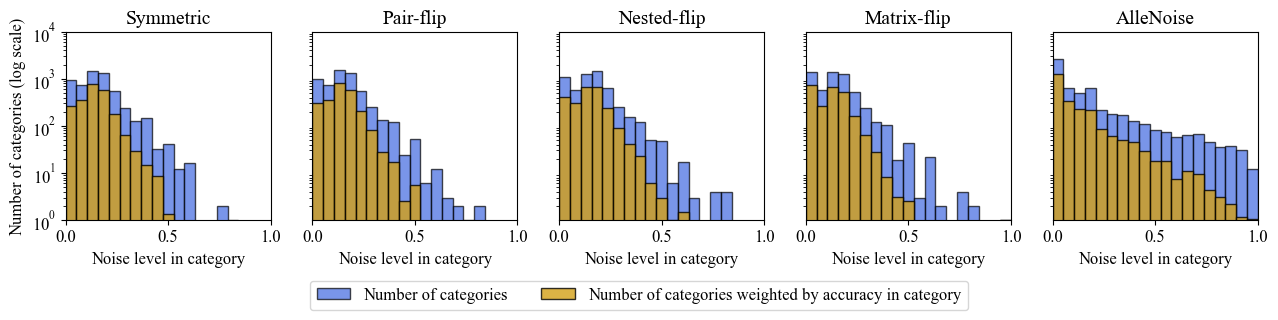

In [107]:
fig, axes = plt.subplots(1, len(PREDICTIONS_DIR), figsize=(13, 3))
plt.rcParams["font.family"] = "Times New Roman"

for idx, noise_type in enumerate(PREDICTIONS_DIR):
    mapping_df = pd.read_json(category_mapping_path[noise_type], typ='series')
    label_to_id_df = pd.Series(
        index=mapping_df.values, 
        data=mapping_df.index
    )

    predictions_df = pd.read_json(predictions_path[noise_type])

    # Predictions arrive in batches, let's reshape them into a single df
    predictions_df = predictions_df.apply(lambda row: pd.DataFrame({'indices': row['indices'], 'targets': row['targets']}), axis=1)
    predictions_df = pd.concat(predictions_df.tolist(), ignore_index=True)

    # Remove invalid labels
    predictions_df = predictions_df[(predictions_df.targets != -1) & (predictions_df.indices != -1)]

    # Map labels to category_ids
    predictions_df["indices"] = predictions_df.indices.map(label_to_id_df)
    predictions_df["targets"] = predictions_df.targets.map(label_to_id_df)

    # Calculate accuracy for each true label (the test split has clean labels)
    predictions_df["correct"] = (predictions_df.indices == predictions_df.targets)
    accuracy = predictions_df.groupby("targets").correct.mean().rename("accuracy")

    # Compare accuracy with true noise level
    categories_df = pd.concat([true_noise_level[noise_type], accuracy], axis=1).fillna(1)

    # Plot histograms of noise level per category
    bins = np.linspace(0, 1, 20)
    counts, bin_edges = np.histogram(categories_df['true_noise_level'], bins=bins)
    weighted_counts, _ = np.histogram(categories_df['true_noise_level'], bins=bins, weights=categories_df['accuracy'])
    bar_width = bin_edges[1] - bin_edges[0]

    ax = axes[idx]
    ax.bar(bin_edges[:-1]+bar_width/2, counts, width=bar_width, log=True, alpha=0.7, label=('Number of categories' if idx==1 else None), color='#4169E1', edgecolor='black')
    ax.bar(bin_edges[:-1]+bar_width/2, weighted_counts, width=bar_width, log=True, alpha=0.8, label=('Number of categories weighted by accuracy in category' if idx==1 else None), color='#D4A017', edgecolor='black')

    ax.set_xlabel("Noise level in category", fontsize=12)
    ax.set_xlim([0, 1])
    ax.set_xticks([0.0, 0.5, 1.0])

    if idx == 0:
        ax.set_ylabel("Number of categories (log scale)", fontsize=12)
    else:
        ax.set_yticks([])

    ax.set_ylim([10**0, 10**4])
    
    ax.set_title(noise_type, fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)


fig.legend(loc="lower center", bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=12, frameon=True)

plt.tight_layout()
plt.savefig("histograms.svg", format="svg", dpi=300)
plt.show()

## True noise level vs. observed noise level

In [108]:
PREDICTIONS_DIR = {
    "Symmetric": "gs://kraken-anchor/task-data/LFND-99/lfnd-99-v5-sym15-baseline-cv-2-20241203133143",
    # "Pair-flip": "gs://kraken-anchor/task-data/LFND-99/lfnd-99-v5-pairflip15-baseline-cv-20240902104937",
    "Nested-flip": "gs://kraken-anchor/task-data/LFND-99/lfnd-99-v5-nestedflip15-baseline-cv-20241202204723",
    "Matrix-flip": "gs://kraken-anchor/task-data/LFND-99/lfnd-99-v5-matrixflip15-baseline-cv-20241203001505",
    # "AlleNoise": "gs://kraken-anchor/task-data/LFND-99/lfnd-99-v5-prod15-baseline-cv-20240826143839",
}
# We always pick fold 0

predictions_path = dict()
category_mapping_path = dict()
for noise_type, job_dir in PREDICTIONS_DIR.items():
    predictions_path[noise_type] = job_dir + "/predictions.json"
    category_mapping_path[noise_type] = job_dir + "/category_mapping/category_mapping.json"

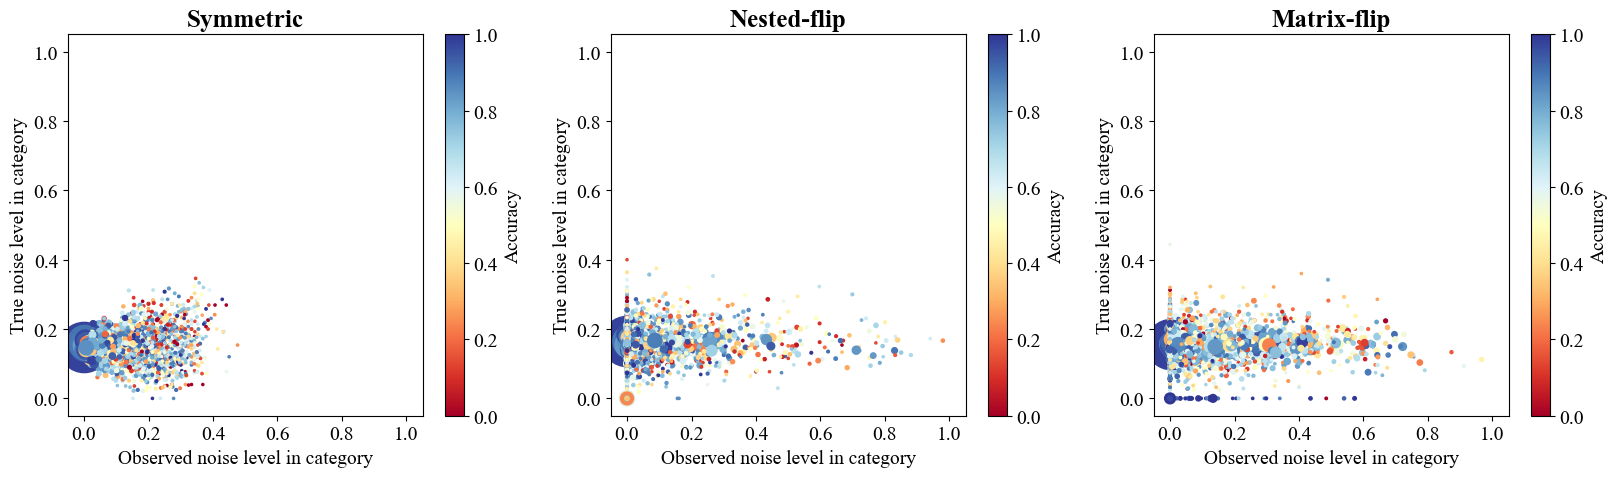

In [110]:
# fig, axes = plt.subplots(1, len(PREDICTIONS_DIR), figsize=(11, 5))
fig, axes = plt.subplots(1, len(PREDICTIONS_DIR), figsize=(16.5, 5))
plt.rcParams["font.size"] = 14

for idx, noise_type in enumerate(PREDICTIONS_DIR):
    mapping_df = pd.read_json(category_mapping_path[noise_type], typ='series')
    label_to_id_df = pd.Series(
        index=mapping_df.values, 
        data=mapping_df.index
    )

    predictions_df = pd.read_json(predictions_path[noise_type])

    # Predictions arrive in batches, let's reshape them into a single df
    predictions_df = predictions_df.apply(lambda row: pd.DataFrame({'indices': row['indices'], 'targets': row['targets']}), axis=1)
    predictions_df = pd.concat(predictions_df.tolist(), ignore_index=True)

    # Remove invalid labels
    predictions_df = predictions_df[(predictions_df.targets != -1) & (predictions_df.indices != -1)]

    # Map labels to category_ids
    predictions_df["indices"] = predictions_df.indices.map(label_to_id_df)
    predictions_df["targets"] = predictions_df.targets.map(label_to_id_df)

    # Calculate accuracy for each true label (the test split has clean labels)
    predictions_df["correct"] = (predictions_df.indices == predictions_df.targets)
    accuracy = predictions_df.groupby("targets").correct.mean().rename("accuracy")

    # Compare accuracy with true noise level
    categories_df = pd.concat([true_noise_level[noise_type], observed_noise_level[noise_type], category_size[noise_type], accuracy], axis=1).fillna(1)

    # Plot true noise level vs. observed noise level
    ax = axes[idx]
    categories_to_plot_df = {
        key: categories_df[key][categories_df['category_size'] >= 25]
        for key in categories_df
    }
    plot = ax.scatter(
        x=categories_to_plot_df['observed_noise_level'], 
        y=categories_to_plot_df['true_noise_level'],
        s=categories_to_plot_df['category_size']*0.1,
        c=categories_to_plot_df['accuracy'],
        cmap="RdYlBu"
    )
    
    ax.set_xlim([-0.05, 1.05])
    ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_ylim([-0.05, 1.05])

    cbar = plt.colorbar(plot)
    cbar.set_label("Accuracy", fontsize=14)

    ax.set_xlabel("Observed noise level in category", fontsize=14)
    ax.set_ylabel("True noise level in category", fontsize=14)
    ax.set_title(noise_type, fontsize=18, fontweight="bold")

plt.tight_layout()
# plt.savefig("scatter_plots.svg", format="svg", dpi=300)
plt.savefig("scatter_plots_appendix.svg", format="svg", dpi=300)
plt.show()

## Accuracy vs. category size

In [111]:
PREDICTIONS_DIR = {
    "AlleNoise": "gs://kraken-anchor/task-data/LFND-99/lfnd-99-v5-prod15-baseline-cv-20240826143839",
}
# We always pick fold 0

predictions_path = dict()
category_mapping_path = dict()
for noise_type, job_dir in PREDICTIONS_DIR.items():
    predictions_path[noise_type] = job_dir + "/predictions.json"
    category_mapping_path[noise_type] = job_dir + "/category_mapping/category_mapping.json"

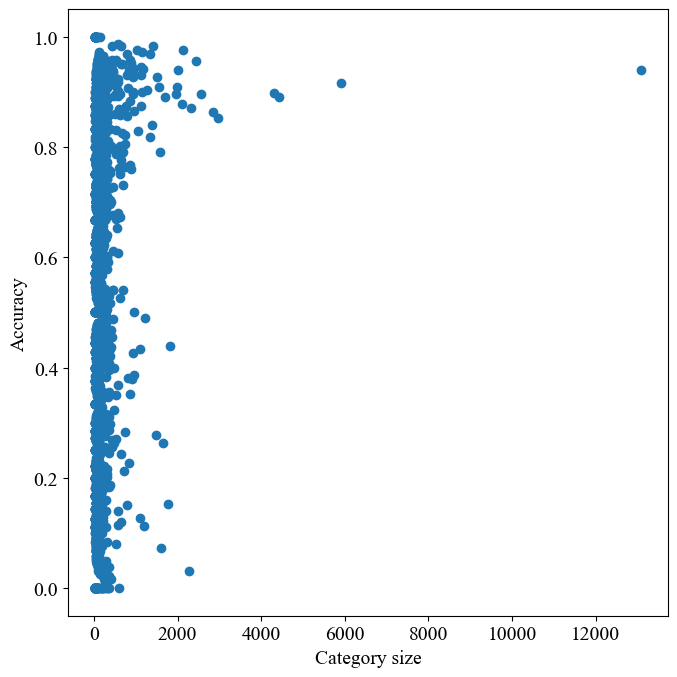

In [125]:
fig = plt.figure(figsize=(7, 7))
ax = plt.gca()
noise_type = "AlleNoise"

mapping_df = pd.read_json(category_mapping_path[noise_type], typ='series')
label_to_id_df = pd.Series(
    index=mapping_df.values, 
    data=mapping_df.index
)

predictions_df = pd.read_json(predictions_path[noise_type])

# Predictions arrive in batches, let's reshape them into a single df
predictions_df = predictions_df.apply(lambda row: pd.DataFrame({'indices': row['indices'], 'targets': row['targets']}), axis=1)
predictions_df = pd.concat(predictions_df.tolist(), ignore_index=True)

# Remove invalid labels
predictions_df = predictions_df[(predictions_df.targets != -1) & (predictions_df.indices != -1)]

# Map labels to category_ids
predictions_df["indices"] = predictions_df.indices.map(label_to_id_df)
predictions_df["targets"] = predictions_df.targets.map(label_to_id_df)

# Calculate accuracy for each true label (the test split has clean labels)
predictions_df["correct"] = (predictions_df.indices == predictions_df.targets)
accuracy = predictions_df.groupby("targets").correct.mean().rename("accuracy")

# Compare accuracy with true noise level
categories_df = pd.concat([true_noise_level[noise_type], observed_noise_level[noise_type], category_size[noise_type], accuracy], axis=1).fillna(1)

# Plot true noise level vs. observed noise level
categories_to_plot_df = {
    key: categories_df[key][categories_df['category_size'] >= 25]
    for key in categories_df
}
plot = plt.scatter(
    x=categories_to_plot_df['category_size'], 
    y=categories_to_plot_df['accuracy'],
)

ax.set_xlabel("Category size", fontsize=14)
ax.set_ylabel("Accuracy", fontsize=14)

plt.tight_layout()
plt.savefig("accuracy_vs_category_size.svg", format="svg", dpi=300)
plt.show()

In [127]:
categories_df["category_size"].corr(categories_df["accuracy"])

0.13424961273841657